# P1 · Evaluation and repeatable experiments

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python and PyTorch. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys, math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.set_num_threads(1)
torch.manual_seed(7)
print("Python", sys.version.split()[0], "· PyTorch", torch.__version__, "· CPU")
print("Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.")


Python 3.12.3 · PyTorch 2.10.0+cpu · CPU
Reference environment: Python 3.12 / PyTorch 2.10. Run with Colab's installed PyTorch or the course requirements.txt.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P1.16 · Evaluation and repeatable experiments

Module mode controls behaviors such as dropout. Grad mode independently controls autograd recording.

**Prerequisites:** Perform one training step

**Predict:** Does eval disable autograd?

**Mental model:** Two switches often appear together when evaluating a model, but they control different behavior. Module mode and gradient recording should be understood independently.

### Why this operation exists

Two switches often appear together when evaluating a model, but they control different behavior. Module mode and gradient recording should be understood independently.

Train and eval change modules that define mode-dependent behavior. Dropout is a concrete example: its training behavior randomly removes and rescales entries.

No grad stops recording operations for differentiation in a region. It does not automatically put modules into evaluation mode.

Evaluation mode does not stop autograd either. A model can produce differentiable evaluation-mode outputs when that is what the program needs.

Seeded randomness makes small experiments easier to compare. Reproducibility still depends on the operation, runtime and device, not on a seed alone.

### Follow the values

The input consists of eight ones. The first experiment uses dropout probability one half, meaning each training entry is independently eligible to be dropped.

In training mode, some entries become zero and retained entries are rescaled. A particular short sample need not contain exactly half zeros.

In evaluation mode, dropout returns the original values without dropping them. This mode change is visible even with the same input.

The evaluation result still requires gradients because the input does. Eval has not disabled recording.

Inside no grad, a new calculation produces doubled values without a recorded gradient dependency. Change the dropout probability and compare which stages are affected.

In [3]:
FRAMES.clear()
change = 0
torch.manual_seed(7)
drop = nn.Dropout(.25 if change else .5)
x = torch.ones(8, requires_grad=True)
show("Input and dropout probability", {"x": x.detach().tolist(), "p": drop.p})
drop.train()
training = drop(x)
show("Training-mode output", training)
drop.eval()
evaluation = drop(x)
show("Evaluation-mode output", evaluation)
show("Eval still records gradients", evaluation.requires_grad)
with torch.no_grad():
    quiet = drop(x*2)
show("Independent no-grad region", {"values": quiet.tolist(), "requires_grad": quiet.requires_grad})

Input and dropout probability: {"x": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], "p": 0.5}
Training-mode output: [2.0, 2.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0]
  shape [8] · torch.float32 · cpu
Evaluation-mode output: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  shape [8] · torch.float32 · cpu
Eval still records gradients: true
Independent no-grad region: {"values": [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0], "requires_grad": false}


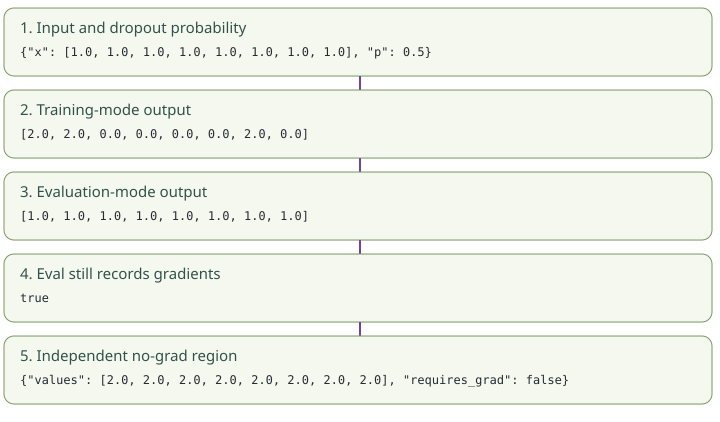

In [4]:
draw_trace()

### Read the implementation

Call train before training-mode behavior and eval before evaluation-mode behavior. The call recursively updates registered submodules.

Use no grad around calculations that do not need a backward graph. Inference mode is a stronger option with additional restrictions on later autograd use.

Seed a generator when you want an isolated stream of random draws, and record the runtime used for repeatable examples. A global seed affects several later random operations.

Keep tensors and model parameters on compatible devices. When comparing floating-point outputs, use tolerances appropriate to their precision and numerical scale.

Restore training mode after validation if more optimization follows. Context managers restore their own grad mode, while eval is a module state change you must manage.

### Change one thing

**Use dropout probability 0.25**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
torch.manual_seed(7)
drop = nn.Dropout(.25 if change else .5)
x = torch.ones(8, requires_grad=True)
show("Input and dropout probability", {"x": x.detach().tolist(), "p": drop.p})
drop.train()
training = drop(x)
show("Training-mode output", training)
drop.eval()
evaluation = drop(x)
show("Evaluation-mode output", evaluation)
show("Eval still records gradients", evaluation.requires_grad)
with torch.no_grad():
    quiet = drop(x*2)
show("Independent no-grad region", {"values": quiet.tolist(), "requires_grad": quiet.requires_grad})

Input and dropout probability: {"x": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], "p": 0.25}
Training-mode output: [1.3333333730697632, 1.3333333730697632, 0.0, 1.3333333730697632, 0.0, 0.0, 1.3333333730697632, 1.3333333730697632]
  shape [8] · torch.float32 · cpu
Evaluation-mode output: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
  shape [8] · torch.float32 · cpu
Eval still records gradients: true
Independent no-grad region: {"values": [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0], "requires_grad": false}


### A useful distinction

eval and no_grad are independent. LayerNorm does not use BatchNorm-style running statistics.

In [6]:
g1 = torch.Generator().manual_seed(17)
g2 = torch.Generator().manual_seed(17)
assert torch.equal(torch.rand(5,generator=g1), torch.rand(5,generator=g2))
with torch.inference_mode():
    output = nn.Linear(2,2)(torch.ones(1,2))
assert not output.requires_grad
print("Seeds reproduced these CPU draws; inference output needs no backward graph.")

Seeds reproduced these CPU draws; inference output needs no backward graph.


### ✋ Your turn

Put whether nn.Dropout(0.5).eval()(torch.ones(2, requires_grad=True)) requires gradients in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer is True, 'eval and no_grad are independent. LayerNorm does not use BatchNorm-style running statistics.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = nn.Dropout(0.5).eval()(torch.ones(2, requires_grad=True)).requires_grad

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer is True, 'eval and no_grad are independent. LayerNorm does not use BatchNorm-style running statistics.'
    print("✓ right:", answer)

✓ right: True


### Reconnect to the transformer

Our tiny model has no dropout layer, but Phyll does. Eval therefore changes Phyll's dropout behavior even when a tiny-model demonstration appears unchanged.

LayerNorm uses current-input feature statistics in both modes. Do not transfer BatchNorm's running-statistics behavior to LayerNorm.

The generation method disables gradients because generation does not backpropagate through sampled text. Evaluation mode is still a separate architectural concern.

The training unit uses fixed evaluation batches and recorded seeds to make comparisons meaningful. Identical seeds do not promise bitwise equality across every platform.

Next, use evaluation outputs to choose and append one new token at a time.

```python
model.eval()
with torch.no_grad():
    logits, loss = model(x, targets)
model.train()
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Does eval disable autograd?

<details><summary>Check your explanation</summary>

No; module mode and grad mode are independent. eval and no_grad are independent. LayerNorm does not use BatchNorm-style running statistics.

</details>